Accuracy: 0.8734177215189873

Confusion Matrix:
 [[24  2]
 [ 8 45]]

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.92      0.83        26
           1       0.96      0.85      0.90        53

    accuracy                           0.87        79
   macro avg       0.85      0.89      0.86        79
weighted avg       0.89      0.87      0.88        79



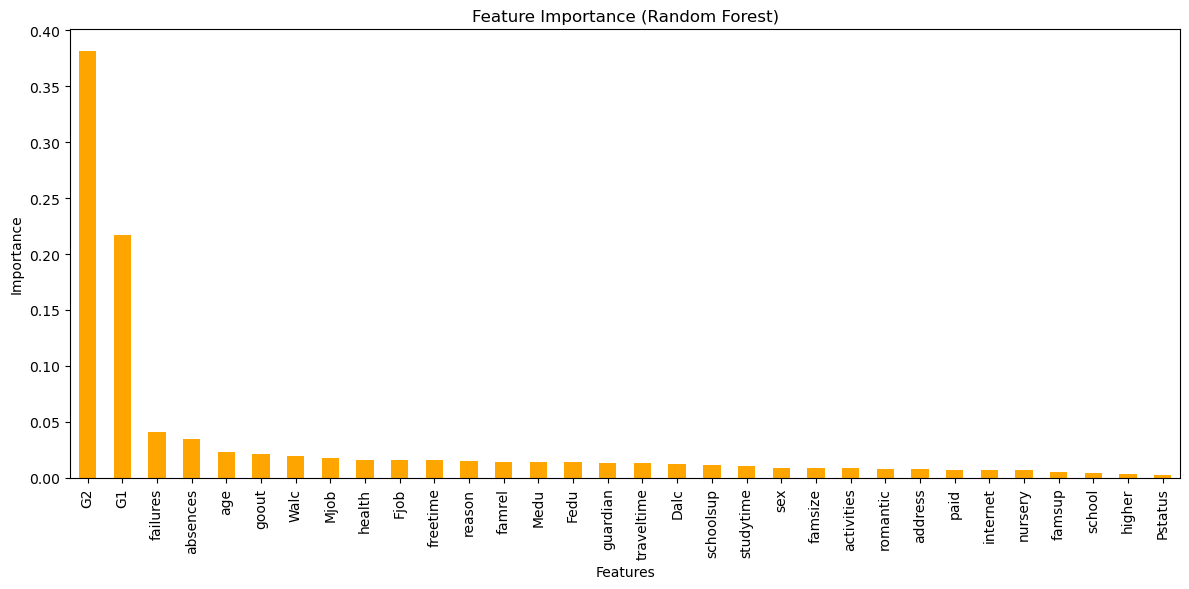

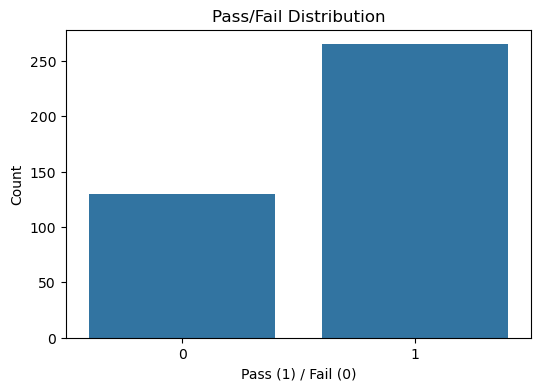

In [1]:
# =========================
# Student Performance Project
# Random Forest Classifier (Pass/Fail)
# =========================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# -------------------------
# 1️⃣ Load Dataset
# -------------------------
df = pd.read_csv("student-mat.csv", sep=";")

# -------------------------
# 2️⃣ Create Pass/Fail Target
# -------------------------
df['pass_fail'] = df['G3'].apply(lambda x: 1 if x >= 10 else 0)

# -------------------------
# 3️⃣ Encode Categorical Features
# -------------------------
label_enc = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = label_enc.fit_transform(df[col])

# -------------------------
# 4️⃣ Split Features & Target
# -------------------------
X = df.drop(['G3', 'pass_fail'], axis=1)
y = df['pass_fail']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -------------------------
# 5️⃣ Train Random Forest Classifier
# -------------------------
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'  # helps with minority class (Fail)
)
rf_model.fit(X_train, y_train)

# -------------------------
# 6️⃣ Make Predictions
# -------------------------
y_pred = rf_model.predict(X_test)

# -------------------------
# 7️⃣ Evaluate Model
# -------------------------
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# -------------------------
# 8️⃣ Feature Importance
# -------------------------
feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(12,6))
feature_importance.plot(kind='bar', color='orange')
plt.title("Feature Importance (Random Forest)")
plt.ylabel("Importance")
plt.xlabel("Features")
plt.tight_layout()
plt.show()

# -------------------------
# 9️⃣ Optional: Plot Pass/Fail Distribution
# -------------------------
plt.figure(figsize=(6,4))
sns.countplot(x='pass_fail', data=df)
plt.title("Pass/Fail Distribution")
plt.xlabel("Pass (1) / Fail (0)")
plt.ylabel("Count")
plt.show()


                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.860759   0.956522  0.830189  0.888889
1        Random Forest  0.873418   0.957447  0.849057  0.900000


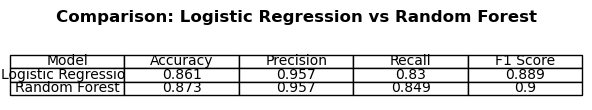

In [2]:
# =========================
# Compare Logistic Regression vs Random Forest
# =========================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Load Dataset
df = pd.read_csv("student-mat.csv", sep=";")

# Create Pass/Fail target
df['pass_fail'] = df['G3'].apply(lambda x: 1 if x >= 10 else 0)

# Encode categorical features
label_enc = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = label_enc.fit_transform(df[col])

# Split data
X = df.drop(['G3', 'pass_fail'], axis=1)
y = df['pass_fail']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# Random Forest
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Calculate metrics
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ]
})

# Display results
print(results)

# Plot as a table image
fig, ax = plt.subplots(figsize=(6, 1.2))
ax.axis('off')
table = ax.table(
    cellText=results.round(3).values,
    colLabels=results.columns,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)
plt.title("Comparison: Logistic Regression vs Random Forest", pad=20, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
